After completing Andrej Karptahy's mini course - 'The spelled-out intro to neural networks and backpropagation' where he has built an engine that computes gradients of nodes with respect to the output node via backpropagation, it really enspired me. I was writing the code in parallel with him, and I enjoyed it a lot. Thus, after ending up the video, in order to strengthen the knowledge I've gained. I decied to build the smae thing with my own hands witout any help from beyond. I hope this tiny little project will the finished. 

In a week will start my 2nd semester in the University, I've picked up i think too much courses, worth 39 ects, hope I will have enough time to devote to this project. 

In [1]:
import torch 
import numpy as np
from graphviz import Digraph


In [156]:
from turtle import backward
from optree.typing import Children


class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        
        self.grad = 0
        self._backward = lambda: None
        
        self._children = _children
        self._prev = set(_children)
        self._op = _op
        
    def __repr__(self):
        return f'Value(data={self.data})'
    
    
    def backward(self):
        """
            Autocomputing the gradients via sorting the computational graph in topological order
            and backpropagating through it and computing the partial derivatives of the output
            with respect to each node
        """
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for children in v._prev:
                    build_topo(children)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1
        for v in reversed(topo):
            v._backward()
    
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _bakcward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _bakcward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        return out
        
    
    
    
    
    
    
    
    def __radd__(self, other):
        return self + other
    

In [162]:
a = Value(5)
b = Value(6)
c = a + b
d = c + 5
e = Value(10)
L = d + e

In [163]:
L.backward()


In [109]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f}" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

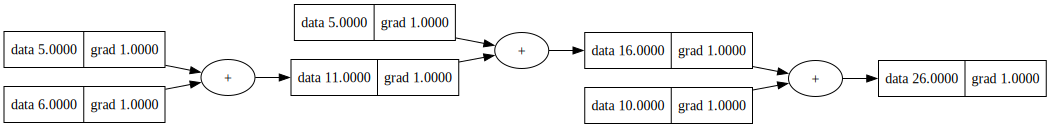

In [164]:
draw_dot(L)

In [ ]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot